## Análise Exploratória de Dados



In [2]:
import pandas as pd
import tensorflow as tf
import numpy as np
import os

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Primeiramente, vamos analisar o balanceamento das classes:

In [4]:
df = pd.read_csv("/content/drive/MyDrive/MDC_data/train-metadata.csv", index_col=0)
df.target.value_counts(normalize=True)

,proportion
target,
0,0.821484
1,0.178516


Nesse caso, percebemos que conjunto de dados é expressivamente desbalanceado, apresentando uma distribuição majoritaria da classe 0, que representa lesões benignas.

Para obtermos uma intuição visual sobre as imagens, devemos primeiramente carregar o conjunto de figuras:

In [10]:
IMAGE_SIZE = (224, 224)

def load_and_preprocess(file_path, label):
    image_binary = tf.io.read_file(file_path)
    image_tf = tf.image.decode_jpeg(image_binary, channels=3)
    image = tf.image.resize(image_tf, IMAGE_SIZE)
    image = image / 255.0

    return image, label



In [11]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 64

base_dir = '/content/drive/MyDrive/MDC_data/train-image/image/'
file_paths = [os.path.join(base_dir, f'{img_id}.jpg') for img_id in df['isic_id']]
labels = df['target'].values

path_ds = tf.data.Dataset.from_tensor_slices((tf.constant(file_paths), tf.constant(labels)))

image_ds = path_ds.map(load_and_preprocess,
                       num_parallel_calls=tf.data.AUTOTUNE)

dataset = image_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Vamos obter 5 amostras de casos malignos e de casos benignos para fazer uma pra visualização das amostras:

In [29]:
images_label_0 = []
images_label_1 = []
labels_label_0 = []
labels_label_1 = []

count_label_0 = 0
count_label_1 = 0

for batch_images, batch_labels in dataset:
    for i in range(len(batch_labels)):
        image = batch_images[i].numpy()
        label = batch_labels[i].numpy()

        if label == 0 and count_label_0 < 5:
            images_label_0.append(image)
            labels_label_0.append(label)
            count_label_0 += 1
        elif label == 1 and count_label_1 < 5:
            images_label_1.append(image)
            labels_label_1.append(label)
            count_label_1 += 1

        if count_label_0 == 5 and count_label_1 == 5:
            break

    if count_label_0 == 5 and count_label_1 == 5:
        break

In [41]:
images = images_label_0 + images_label_1
labels = labels_label_0 + labels_label_1
labels = ['Benigno' if x == 0 else 'Maligno' for x in labels]

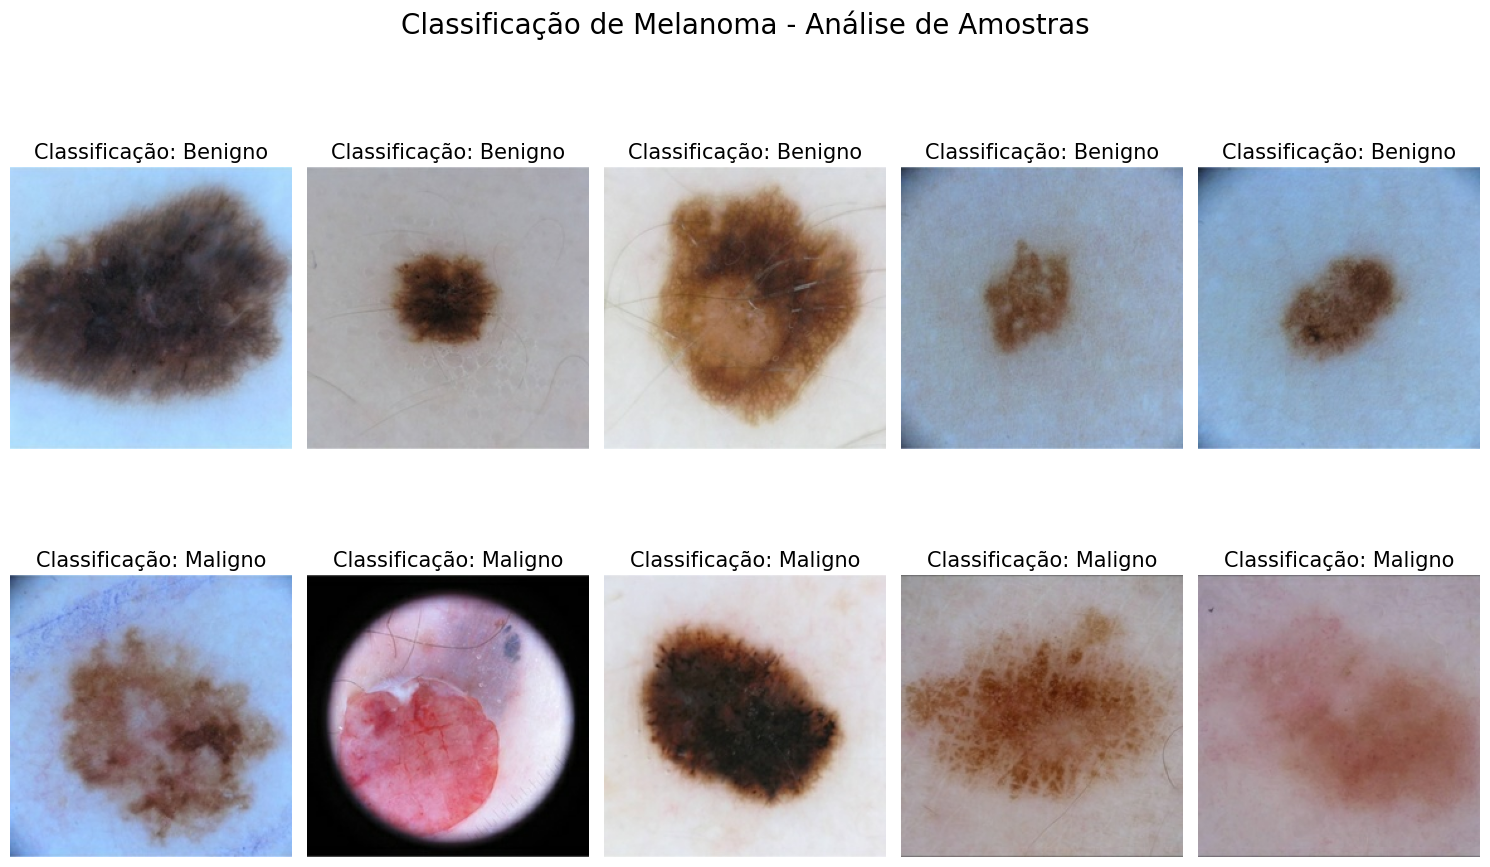

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.suptitle("Classificação de Melanoma - Análise de Amostras", fontsize=20)
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i])

    plt.title(f"Classificação: {labels[i]}", fontsize = 15)
    plt.axis('off')

plt.tight_layout()
plt.show()

Podemos realizar algumas análises sobre as imagens dessas amostras:
- A olho nu é praticamente imperceptível a diferença entre amostras malignas ou benignas
- Algumas imagens apresentam coloração azulada
- Há uma iagem com uma borda preta circular

Isso é um indicador que as imagens devem receber alguns tratamentos afim de normalizar a escala de cor e/ou lidar com bordas